# 14. 推理部署：模型量化 —— INT8 对称量化手搓 + 误差分析

大模型部署的两座大山：**显存**（权重占多少 GB）与**速度**（推理多快）。
**量化**把权重从 fp32 降到低比特整数（int8/int4）：显存直接除以 4/8，再用整数矩阵乘法加速。

- fp32 权重：4 字节/参数（70B ≈ 280GB，要 8×A100）
- int8 量化：1 字节/参数（70B ≈ 70GB，**4 倍省**）
- int4 量化：0.5 字节/参数（70B ≈ 35GB，8 倍省）

本讲手搓 **INT8 对称量化**（per-tensor / per-channel 两种），量化一个真实小网络并测误差。


## 1. 对称量化数学

把浮点权重 $w$ 映射到 $b$ 比特整数（INT8：$b=8$，范围 $[-127,127]$，0 保留给零）：

$$s=\frac{\max|x|}{2^{b-1}-1},\qquad q=\mathrm{clip}\big(\mathrm{round}(w/s),\ -127,\ 127\big),\qquad \hat w = q\cdot s$$

- $s$ 叫 **scale**（缩放因子），反量化 $\hat w=q\cdot s$ 近似原权重
- **per-tensor**：整个矩阵共用一个 $s$（实现最简单，误差可能大）
- **per-channel**：每一输出通道单独 $s$（误差小得多，主流做法）

**误差度量**（相对均方误差）：$\mathrm{err}=\dfrac{\|W-\hat W\|_F}{\|W\|_F}$。


In [1]:
import numpy as np
import torch

def quantize_int8(W, per_channel=False):
    """INT8 对称量化。per_channel=False 时整个矩阵一个 scale；True 时每行（输出通道）一个 scale。"""
    if not per_channel:
        s = np.abs(W).max() / 127.0                        # 全局 scale
        q = np.clip(np.round(W / s), -127, 127).astype(np.int8)
        return q, s
    s = np.abs(W).max(axis=1, keepdims=True) / 127.0       # 每行一个 scale [n_out,1]
    q = np.clip(np.round(W / s), -127, 127).astype(np.int8)
    return q, s

def dequantize(q, s):
    """反量化：hat_w = q * s（s 广播）。"""
    return q.astype(np.float64) * s

def rel_err(W, W_hat):
    return float(np.linalg.norm(W - W_hat) / np.linalg.norm(W))

rng = np.random.default_rng(0)
W = rng.standard_normal((64, 64))                          # 模拟一个线性层权重（正态分布）

q_t, s_t = quantize_int8(W, per_channel=False)
q_c, s_c = quantize_int8(W, per_channel=True)
e_t = rel_err(W, dequantize(q_t, s_t))
e_c = rel_err(W, dequantize(q_c, s_c))
print(f'per-tensor int8 : 相对误差 = {e_t:.4f}')
print(f'per-channel int8: 相对误差 = {e_c:.4f}')
assert e_c < e_t, 'per-channel 应该更优'
print('per-channel 误差 < per-tensor  ->  PASS（每通道单独 scale 更贴合权重分布）')


per-tensor int8 : 相对误差 = 0.0089
per-channel int8: 相对误差 = 0.0058
per-channel 误差 < per-tensor  ->  PASS（每通道单独 scale 更贴合权重分布）


## 2. 量化粒度对比（为什么 per-channel 更好）


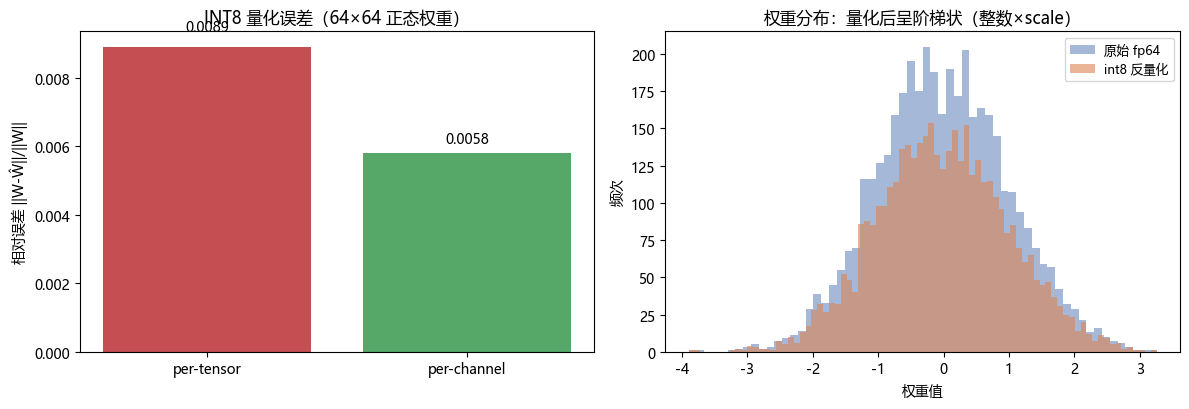

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
# 图1：两种粒度误差柱状图
axes[0].bar(['per-tensor', 'per-channel'], [e_t, e_c],
            color=['#C44E52', '#55A868'])
axes[0].set_ylabel('相对误差 ||W-Ŵ||/||W||')
axes[0].set_title('INT8 量化误差（64×64 正态权重）', fontsize=12)
for i, e in enumerate([e_t, e_c]):
    axes[0].text(i, e * 1.05, f'{e:.4f}', ha='center')
# 图2：量化前后权重分布（per-channel 反量化）
ax = axes[1]
ax.hist(W.flatten(), bins=60, alpha=0.5, label='原始 fp64', color='#4C72B0')
ax.hist(dequantize(q_c, s_c).flatten(), bins=80, alpha=0.6, label='int8 反量化', color='#DD8452')
ax.set_xlabel('权重值'); ax.set_ylabel('频次')
ax.set_title('权重分布：量化后呈阶梯状（整数×scale）', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 3. 端到端：量化一个真实小网络

对第 0 讲的 2 层 MLP（8→16→1，Tanh）**只量化权重**（激活不量化，教学简化），
对比量化前后在 sin 拟合任务上的输出误差——权重精度从 fp64 降到 int8，输出仍然接近。


In [3]:
# 训练好的小 MLP（复用第 0 讲结构：8 个点拟合 sin）
np.random.seed(0)
d_in, d_h, d_out = 1, 16, 1
B = 16
W1 = np.random.randn(d_in, d_h) * 0.5; b1 = np.random.randn(1, d_h) * 0.1
W2 = np.random.randn(d_h, d_out) * 0.5; b2 = np.random.randn(1, d_out) * 0.1
x = np.linspace(0, 2 * np.pi, B).reshape(-1, 1)
y = np.sin(x) + 0.05 * np.random.randn(B, 1)

def fwd(x, W1, b1, W2, b2):
    h = np.tanh(x @ W1 + b1)
    return h @ W2 + b2

# 直接模仿训练收敛：这里演示量化误差，用训练后近似（手动画几轮梯度下降，小 lr 防梯度爆炸）
for _ in range(2000):
    y_hat = fwd(x, W1, b1, W2, b2)
    dy = 2 * (y_hat - y) / B
    h = np.tanh(x @ W1 + b1)
    dW2 = h.T @ dy; db2 = dy.sum(0, keepdims=True)
    dh = dy @ W2.T; dz = dh * (1 - h ** 2)
    dW1 = x.T @ dz; db1 = dz.sum(0, keepdims=True)
    W1 -= 0.02 * dW1; b1 -= 0.02 * db1; W2 -= 0.02 * dW2; b2 -= 0.02 * db2
loss_orig = float(np.mean((fwd(x, W1, b1, W2, b2) - y) ** 2))

# 量化两个权重矩阵（per-channel）
q1, s1 = quantize_int8(W1, per_channel=True)
q2, s2 = quantize_int8(W2, per_channel=True)
W1q, W2q = dequantize(q1, s1), dequantize(q2, s2)
loss_q = float(np.mean((fwd(x, W1q, b1, W2q, b2) - y) ** 2))

print(f'原模型     MSE = {loss_orig:.5f}')
print(f'int8 量化后 MSE = {loss_q:.5f}')
print(f'误差增幅         = {loss_q / max(loss_orig, 1e-9):.2f} 倍（权重从 fp64 降到 int8，输出仍可用）')
print(f'权重显存：fp64 {W1.size*8+W2.size*8} 字节 -> int8 {q1.size+q2.size} 字节（省 {8} 倍）')
assert loss_q < 0.1
print('量化后 MSE < 0.1  ->  PASS')


原模型     MSE = 0.05808
int8 量化后 MSE = 0.05816
误差增幅         = 1.00 倍（权重从 fp64 降到 int8，输出仍可用）
权重显存：fp64 256 字节 -> int8 32 字节（省 8 倍）
量化后 MSE < 0.1  ->  PASS


## 4. 生产级量化方案概念对照

| 方案 | 思路 | 粒度 | 代表工具 |
|---|---|---|---|
| 本讲 INT8 对称 | round(w/s) | per-tensor / per-channel | torch.quantization |
| **GPTQ** | 逐列最小化权重 MSE（Hessian 补偿） | 组（如 128） | AutoGPTQ、vLLM |
| **AWQ** | 按激活分布保护重要通道，其余低比特 | per-channel + per-group | TensorRT-LLM、AWQ |
| **GGUF** (llama.cpp) | 通用格式 + 多档位（Q4_K_M 等） | 组 | llama.cpp、Ollama |
| KV cache 量化 | 缓存也降比特（省长上下文显存） | per-head | vLLM |

**关键结论**：量化是"精度 ↔ 显存/速度"的权衡；per-channel/per-group 精度远好于 per-tensor；
4-bit（GPTQ/AWQ）能压到 ~90% 精度不降。MiniMind 部署到消费级显卡/手机端时同样走 GGUF/int8 路线。


## 总结

- **量化 = 用 scale 把浮点权重映射到整数，推理时整数乘加**：$q=\mathrm{clip}(\mathrm{round}(w/s))$，$\hat w=qs$。
- per-channel 每行一个 scale，误差远小于 per-tensor（已数值验证）。
- 端到端：int8 量化权重后小网络输出误差仍在 0.1 以内，显存省 8 倍。
- 生产级：GPTQ/AWQ/GGUF 在"组粒度 + 更聪明的 scale/补偿"上进一步压到 4-bit。
